🎯 数据加载成功！正在为你绘制图表...


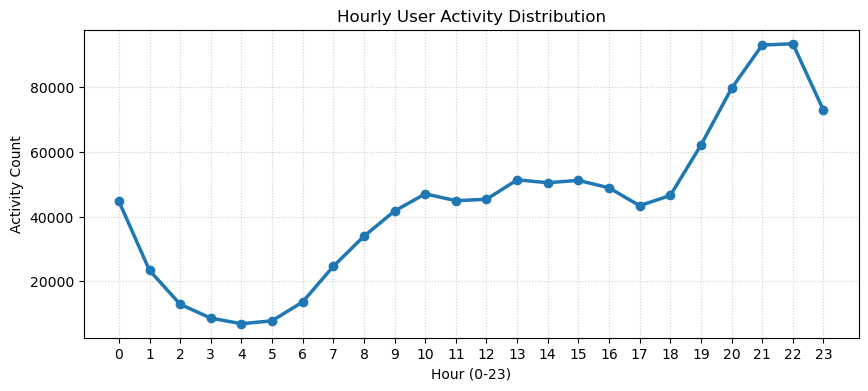

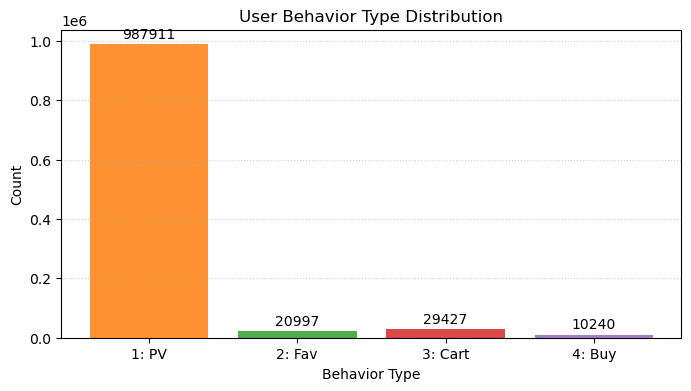

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 启动网页内嵌画图
%matplotlib inline

# 2. 因为 Jupyter 就是在这个文件夹下启动的，直接写文件名就能读！
file_name = "taobao_user_behavior_processed.xlsx"
df_cleaned = pd.read_excel(file_name)

# 3. 补充时间特征
df_cleaned['time'] = pd.to_datetime(df_cleaned['time'], format='%Y-%m-%d %H')
df_cleaned['hour'] = df_cleaned['time'].dt.hour

print("🎯 数据加载成功！正在为你绘制图表...")

# =======================================================
# 【图一】：24小时用户活跃度折线图
# =======================================================
plt.figure(figsize=(10, 4))
hourly_data = df_cleaned['hour'].value_counts().sort_index()
plt.plot(hourly_data.index, hourly_data.values, marker='o', color='#1f77b4', linewidth=2.5)
plt.title('Hourly User Activity Distribution')
plt.xlabel('Hour (0-23)')
plt.ylabel('Activity Count')
plt.xticks(range(0, 24))
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# =======================================================
# 【图二】：电商行为漏斗柱状图
# =======================================================
plt.figure(figsize=(8, 4))
behavior_map = {1: '1: PV', 2: '2: Fav', 3: '3: Cart', 4: '4: Buy'}
df_cleaned['behavior_name'] = df_cleaned['behavior_type'].map(behavior_map)
behavior_counts = df_cleaned['behavior_name'].value_counts().reindex(['1: PV', '2: Fav', '3: Cart', '4: Buy'])

plt.bar(behavior_counts.index, behavior_counts.values, color=['#ff7f0e', '#2ca02c', '#d62728', '#9467bd'], alpha=0.85)
plt.title('User Behavior Type Distribution')
plt.xlabel('Behavior Type')
plt.ylabel('Count')
plt.grid(axis='y', linestyle=':', alpha=0.6)

for x, y in enumerate(behavior_counts.values):
    plt.text(x, y + (max(behavior_counts.values)*0.01), f'{int(y)}', ha='center', va='bottom', fontsize=10)
plt.show()

===== 📊 电商漏斗转化率分析 =====
点击/浏览 (PV): 987911 次
收藏 (Fav): 20997 次 (占比: 2.13%)
加购 (Cart): 29427 次 (占比: 2.98%)
购买 (Buy): 10240 次 (总转化率: 1.04%)

===== 🛒 用户复购分析 =====
在期间内产生过购买行为的总人数: 4330 人
产生过 2 次及以上购买的‘忠诚复购用户’: 2295 人
整体用户复购率: 53.00%



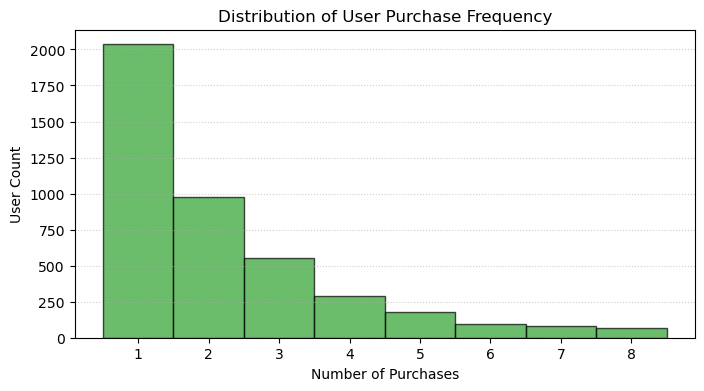

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 统计各项行为的总次数
pv_count = df_cleaned[df_cleaned['behavior_type'] == 1].shape[0]
fav_count = df_cleaned[df_cleaned['behavior_type'] == 2].shape[0]
cart_count = df_cleaned[df_cleaned['behavior_type'] == 3].shape[0]
buy_count = df_cleaned[df_cleaned['behavior_type'] == 4].shape[0]

# 2. 计算转化率 (以 PV 为基准)
print("===== 📊 电商漏斗转化率分析 =====")
print(f"点击/浏览 (PV): {pv_count} 次")
print(f"收藏 (Fav): {fav_count} 次 (占比: {(fav_count/pv_count)*100:.2f}%)")
print(f"加购 (Cart): {cart_count} 次 (占比: {(cart_count/pv_count)*100:.2f}%)")
print(f"购买 (Buy): {buy_count} 次 (总转化率: {(buy_count/pv_count)*100:.2f}%)")
print("================================\n")

# 3. 复购率分析：每个用户的购买次数分布
user_buy_counts = df_cleaned[df_cleaned['behavior_type'] == 4].groupby('user_id').size()
total_buyers = len(user_buy_counts)
repeat_buyers = sum(user_buy_counts > 1)

print("===== 🛒 用户复购分析 =====")
print(f"在期间内产生过购买行为的总人数: {total_buyers} 人")
print(f"产生过 2 次及以上购买的‘忠诚复购用户’: {repeat_buyers} 人")
print(f"整体用户复购率: {(repeat_buyers/total_buyers)*100:.2f}%")
print("================================\n")

# 4. 绘制购买频次分布图
plt.figure(figsize=(8, 4))
plt.hist(user_buy_counts, bins=range(1, 10), align='left', color='#2ca02c', edgecolor='black', alpha=0.7)
plt.title('Distribution of User Purchase Frequency')
plt.xlabel('Number of Purchases')
plt.ylabel('User Count')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()